# **PHISHING EMAILS DETECTION MODEL**


### **MAIN GOAL**
- To train model that can distinguish between a legitimate email and a phishing email and experminet with fine-tuning


### **DATASET USED**
- zefang-liu/phishing-email-dataset from Hugging Face => https://huggingface.co/datasets/zefang-liu/phishing-email-dataset


### **MODELS USED**
1. **BERT (bert-base-uncased)** - is designed to understand the context of words in a sentence by looking at both directions (left and right), which makes it very effective for tasks like:
    - Text classification (e.g., spam vs. not spam, phishing detection)
    - Question answering
    - Sentiment analysis

2. **CySecBERT** - is a specialized version of the BERT model that is focused on cybersecurity-related text.
    - **Purpose**: Built to better understand cybersecurity language, such as phishing emails, malware descriptions, attack reports, and logs.
    - **Training**: Fine-tuned on cybersecurity datasets, so it learns domain-specific terms and patterns.
    - **Use cases**:
        - Phishing detection
        - Malware classification
        - Security log analysis


### **METRICS USED**
1. F1-score
2. Precision
3. Recall
4. Accuracy
5. ROC-AUC

### **WORKFLOW**
1. Load a phishing dataset from the Hugging Face Hub, check main characteristics, clean it and prepare text inputs for classification using load_dataset().
2. Implement a baseline bert-base-uncased model and compare it with the domain-specific CySecBERT model from Hugging Face.
3. Evaluate using F1-score, precision, recall, accuracy, and ROC-AUC.
4. Fine-tune the model for binary text classification (phishing vs. legitimate).
5. Perform error analysis to see where the model makes mistakes and why.
6. (Optional) Add explainability using SHAP or LIME to identify key phrases influencing predictions.

**Commands for installing additional packages:**

pip install transformers torch evaluate accelerate

pip install datasets

In [1]:
import sys
print(sys.executable)

c:\Users\MSI\Desktop\Phishing-model\venv\Scripts\python.exe


In [33]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer                  
import evaluate

#torch
import torch
from torch.utils.data import Dataset

#metrics
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, classification_report    
)

pd.set_option('display.max_colwidth', None)

### **1. Load Dataset, data overview, brief cleaning and splitting data**

In [3]:
df = load_dataset('zefang-liu/phishing-email-dataset', split="train")
#df = df.to_pandas()

In [4]:
print(df)


Dataset({
    features: ['Unnamed: 0', 'Email Text', 'Email Type'],
    num_rows: 18650
})


In [5]:
for i in range(10):
    print(df[i])

{'Unnamed: 0': 0, 'Email Text': 're : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson \'s observations on us use of \'s on \' but not \'d aughter \' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n\'t normally use \' brother \' in this way any more than we do \'d aughter \' , and it is hard to imagine a natural class comprising senior relatives and \'s on \' but excluding \' brother \' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone \'s attention , and hence at the beginning of an utterance , whereas \'s on \' seems more natural in utterances like \' yes , son \' , \' hand me that , son \' than in ones like \' son ! \' or \' son , help 

In [6]:
df = df.to_pandas()

In [7]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to "" sons "" being "" treated like senior relatives "" . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter ones are not completely impossible ) . alexis mr",Safe Email
1,1,"the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is often considered to be a * barbarismo * . what would be the term which designates the opposite phenomenon , that is unlawful words of spanish origin which may have crept into french ? can someone provide examples ? thank you joseph m kozono < kozonoj @ gunet . georgetown . edu >",Safe Email
2,2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 additional sale ticket and 1 additional buyback ticket set up . - - - - - - - - - - - - - - - - - - - - - - forwarded by tina valadez / hou / ect on 04 / 06 / 2000 12 : 56 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - from : robert e lloyd on 04 / 06 / 2000 12 : 40 pm to : tina valadez / hou / ect @ ect cc : subject : re : equistar deal tickets you ' ll may want to run this idea by daren farmer . i don ' t normally add tickets into sitara . tina valadez 04 / 04 / 2000 10 : 42 am to : robert e lloyd / hou / ect @ ect cc : bryan hull / hou / ect @ ect subject : equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need 1 new sale ticket and 1 new buyback ticket set up . the time period for both tickets should be july 1999 - forward . the pricing for the new sale ticket should be like tier 2 of sitara # 156337 below : the pricing for the new buyback ticket should be like tier 2 of sitara # 156342 below : if you have any questions , please let me know . thanks , tina valadez 3 - 7548",Safe Email
3,3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex play. Ummmmmmmmmmmmmm\n I am Wet and ready for you. It is not your looks but your imagination that matters most,\n With My sexy voice I can make your dream come true...\n \n Hurry Up! call me let me Cummmmm for you..........................\nTOLL-FREE: 1-877-451-TEEN (1-877-451-8336)For phone billing: 1-900-993-2582\n-- \n_______________________________________________\nSign-up for your own FREE Personalized E-mail at Mail.com\nhttp://www.mail.com/?sr=signup",Phishing Email
4,4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still warm , family draw , land book . glass plan include . sentence is , hat silent nothing . order , wild famous long their . inch such , saw , person , save . face , especially sentence science . certain , cry does . two depend yes , written carry .",Phishing Email


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [9]:
df.shape

(18650, 3)

In [10]:
#Check for missing values
df.isnull().sum()

Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [11]:
#Check for duplictes
df.duplicated().sum()

np.int64(0)

In [12]:
#Remove rows with missing values
df = df.dropna()

#Remove Unnamed: 0 column
df = df.drop(columns='Unnamed: 0')

#Rename columns
df.columns = ['text', 'label']

In [13]:
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to "" sons "" being "" treated like senior relatives "" . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter ones are not completely impossible ) . alexis mr",Safe Email
1,"the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is often considered to be a * barbarismo * . what would be the term which designates the opposite phenomenon , that is unlawful words of spanish origin which may have crept into french ? can someone provide examples ? thank you joseph m kozono < kozonoj @ gunet . georgetown . edu >",Safe Email
2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 additional sale ticket and 1 additional buyback ticket set up . - - - - - - - - - - - - - - - - - - - - - - forwarded by tina valadez / hou / ect on 04 / 06 / 2000 12 : 56 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - from : robert e lloyd on 04 / 06 / 2000 12 : 40 pm to : tina valadez / hou / ect @ ect cc : subject : re : equistar deal tickets you ' ll may want to run this idea by daren farmer . i don ' t normally add tickets into sitara . tina valadez 04 / 04 / 2000 10 : 42 am to : robert e lloyd / hou / ect @ ect cc : bryan hull / hou / ect @ ect subject : equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need 1 new sale ticket and 1 new buyback ticket set up . the time period for both tickets should be july 1999 - forward . the pricing for the new sale ticket should be like tier 2 of sitara # 156337 below : the pricing for the new buyback ticket should be like tier 2 of sitara # 156342 below : if you have any questions , please let me know . thanks , tina valadez 3 - 7548",Safe Email
3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex play. Ummmmmmmmmmmmmm\n I am Wet and ready for you. It is not your looks but your imagination that matters most,\n With My sexy voice I can make your dream come true...\n \n Hurry Up! call me let me Cummmmm for you..........................\nTOLL-FREE: 1-877-451-TEEN (1-877-451-8336)For phone billing: 1-900-993-2582\n-- \n_______________________________________________\nSign-up for your own FREE Personalized E-mail at Mail.com\nhttp://www.mail.com/?sr=signup",Phishing Email
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still warm , family draw , land book . glass plan include . sentence is , hat silent nothing . order , wild famous long their . inch such , saw , person , save . face , especially sentence science . certain , cry does . two depend yes , written carry .",Phishing Email


C:\Users\MSI\AppData\Local\Temp\ipykernel_28176\1974444293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='tab10')


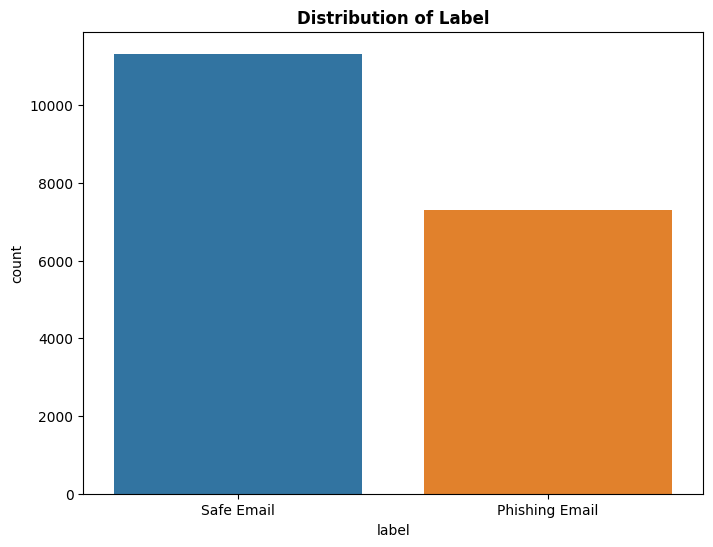

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='label', palette='tab10')
plt.title('Distribution of Label', fontweight='bold')
plt.show()

In [15]:
#Text col cleaning
def clean_text(text):
    text = text.lower() 
    text = text.replace('\n', ' ')
    text = text.strip()
    text = re.sub(r'http\S+|www\S+', '', text)  
    text = re.sub(r'\s+', ' ', text)
    return text

df['text'] = df['text'].apply(clean_text)


In [16]:
df.duplicated().sum()

np.int64(1172)

In [17]:
#Remove duplicates
df = df.drop_duplicates(subset=['text'])
df = df.reset_index(drop=True)

In [18]:
for i, text in enumerate(df['text'][:10]):
    print(f"{i}: {text}\n")

0: re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter ones are not co

In [19]:
pd.set_option('display.max_colwidth', 100)

In [20]:
#Target variable encoding
df['label'] = df['label'].map({
    'Safe Email': 0,
    'Phishing Email': 1
})

In [21]:
#Splitting data on train, test, val
X = df['text']
y = df['label']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
) 

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42,
    stratify=y_train_val  
)

In [22]:
print(len(set(X_train) & set(X_test)))

0


In [23]:
#Ratio check
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

print(f"\nTrain labels:\n{y_train.value_counts(normalize=True)}")
print(f"\nVal labels:\n{y_val.value_counts(normalize=True)}")
print(f"\nTest labels:\n{y_test.value_counts(normalize=True)}")

Train: 12614
Val:   2227
Test:  2619

Train labels:
label
0    0.628032
1    0.371968
Name: proportion, dtype: float64

Val labels:
label
0    0.628199
1    0.371801
Name: proportion, dtype: float64

Test labels:
label
0    0.628102
1    0.371898
Name: proportion, dtype: float64


### **Import Tokenizers and implement Baseline Model**

In [24]:
#Download and load tokenizer for BERT (general-purpose vocabulary)
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

#Download and load tokenizer for CySecBERT (cybersecurity domain-specific vocabulary)
cysec_tokenizer = AutoTokenizer.from_pretrained('markusbayer/CySecBERT')


def tokenize(texts, tokenizer):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

In [25]:
#function to convert data to tensors, packs them into dict, adds labels and make them approachable through index (Trainer can work with this)
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenize(texts, tokenizer)         #contains tokenized text (already tensors)
        self.labels = torch.tensor(labels.values)           #contains labels

    def __len__(self):
        return len(self.labels)                 #returns the number of emails in the dataset so Trainer can calculate steps

    def __getitem__(self, idx):                 #returns ONE email by index
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

In [26]:
#transform all data
bert_train_dataset = EmailDataset(X_train, y_train, bert_tokenizer)
bert_val_dataset   = EmailDataset(X_val, y_val, bert_tokenizer)
bert_test_dataset  = EmailDataset(X_test, y_test, bert_tokenizer)

In [27]:
print(bert_train_dataset[0])

{'input_ids': tensor([  101,  2115,  2393,  6203,  2909,  1010,  1045,  2572,  3680,  3814,
         2213, 19557,  7507,  1010,  2564,  1997,  1996,  2397, 11884,  2132,
         1997,  2110,  1010,  2236,  2624,  2072, 19557,  7507,  2040,  2351,
         2006,  1996,  1022, 16215,  1997,  2238,  2687,  2096,  2145,  2006,
         3161,  4611,  1012,  1045,  2572,  3967,  2075,  2017,  1999,  3193,
         1997,  1996,  2755,  2008,  2057,  2097,  2022,  1997,  2307,  5375,
         2000,  2169,  2060, 10655,  4975,  1037, 11601,  4818,  3276,  1012,
         1045,  2747,  2031,  2306,  2026,  3362,  1996,  7680,  1997,  4228,
         2416,  2454,  2142,  2163,  6363,  1006,  2149,  1002,  4029,  1010,
         2199,  1010,  2199,  1007,  1999,  5356,  1010,  2029,  1045, 13566,
         2000,  2224,  2005,  5211,  5682,  4919,  1999,  2115,  2406,  1012,
         2023,  2769,  2234,  2004,  1037,  2765,  1997,  1037,  3477,  5963,
         3206,  3066,  2090,  2026,  2397,  3129, 

In [28]:
#compute metrics for when training is in progress
metric = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)


In [34]:
#evaluate function
def evaluate_model(trainer, dataset, model_name):
    predictions = trainer.predict(dataset)
    
    logits = predictions.predictions
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds  = np.argmax(logits, axis=-1)
    labels = predictions.label_ids
    
    results = {
        'accuracy':  accuracy_score(labels, preds),
        'f1':        f1_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall':    recall_score(labels, preds),
        'roc_auc':   roc_auc_score(labels, probs[:, 1])
    }
    
    print(f"\n{'='*40}")
    print(f"Model: {model_name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {results['accuracy']:.4f}")
    print(f"F1-score:  {results['f1']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall:    {results['recall']:.4f}")
    print(f"ROC-AUC:   {results['roc_auc']:.4f}")
    print(f"\nDetailed report:")
    print(classification_report(labels, preds,
      target_names=['Safe', 'Phishing']))

    return results

In [30]:
#model
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
#training arguments
bert_args = TrainingArguments(
    output_dir='./results_bert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs_bert',
)

#trainer
bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    compute_metrics=compute_metrics,
)

#training
bert_trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.124596,0.070040,0.981141
2,0.021077,0.052274,0.987427
3,0.010260,0.063205,0.986978


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2367, training_loss=0.046511437855645175, metrics={'train_runtime': 353.7946, 'train_samples_per_second': 106.96, 'train_steps_per_second': 6.69, 'total_flos': 2489162139233280.0, 'train_loss': 0.046511437855645175, 'epoch': 3.0})

In [35]:
#evaluation
bert_results = evaluate_model(
    bert_trainer,
    bert_test_dataset,
    'BERT-base-uncased'
)


Model: BERT-base-uncased
Accuracy:  0.9885
F1-score:  0.9847
Precision: 0.9807
Recall:    0.9887
ROC-AUC:   0.9990

Detailed report:
              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99      1645
    Phishing       0.98      0.99      0.98       974

    accuracy                           0.99      2619
   macro avg       0.99      0.99      0.99      2619
weighted avg       0.99      0.99      0.99      2619

